In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [10, 5]

plt.style.use('ggplot')

from matplotlib import rc
#rc('ps', useafm=True)
rc('pdf', use14corefonts=True)
rc('text', usetex=True)
rc('font', family='sans-serif')
rc('font', **{'sans-serif': ['Computer Modern']})
rc('font', size=14)
rc('axes', grid=False)

In [2]:
import re

RUN_DIR_RE = re.compile(r"M(?P<M>\d+)_nbits(?P<nbits>\d+)")
PS_RE = re.compile(r"ps(?P<ps>\d+)")


def parse_dir_name(dirname: str) -> dict:

    parts = dirname.split("__")
    if len(parts) < 4:
        raise ValueError(f"Unexpected run dir name format: {dirname}")

    train_ds   = parts[0]          # e.g. 'msmarco-passage-train'
    model_name = parts[1]        # e.g. 'tct_colbert'
    pq_impl    = parts[2]           # e.g. 'faiss2opq'
    M_nbits    = parts[3]           # e.g. 'M128_nbits10'
    ps_part    = parts[4] if len(parts) > 4 else ""

    m_match = RUN_DIR_RE.search(M_nbits)
    if not m_match:
        raise ValueError(f"Cannot parse M/nbits from '{M_nbits}' in {dirname}")

    M = int(m_match.group("M"))
    nbits = int(m_match.group("nbits"))

    ps_match = PS_RE.search(ps_part)
    ps = int(ps_match.group("ps")) if ps_match else None

    return {
        "train_ds": train_ds,
        "model": model_name,
        "pq_impl": pq_impl,
        "M": M,
        "nbits": nbits,
        "pq_sample_size": ps,
    }

In [3]:
import pandas as pd
from pathlib import Path

def load_single_metrics_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, index_col=0)
    if "name" not in df.columns:
        raise ValueError(f"'name' column not found in {csv_path}")
    return df

In [4]:
import numpy as np

def collect_all_results(root: Path, split: str = '2019') -> pd.DataFrame:
    rows = []

    for run_dir in root.iterdir():
        if not run_dir.is_dir():
            continue

        metrics_path = run_dir / "runs" / ("test-" + split) / "metrics.csv"
        if not metrics_path.is_file():
            continue

        try:
            meta = parse_dir_name(run_dir.name)
        except ValueError as e:
            # skip dirs that do not follow naming convention
            print(f"[WARN] Skipping {run_dir}: {e}")
            continue

        try:
            df = load_single_metrics_csv(metrics_path)
        except Exception as e:
            print(f"[WARN] Failed to read {metrics_path}: {e}")
            continue
        
        for _, row in df.iterrows():
            rec = dict(meta)  # copy metadata
            rec["variant"] = row["name"]  # e.g. 'baseline', 'JPQ pq'

            # pull the metrics we care about (if present)
            for col in ["R(rel=2)@100", "nDCG@10", "R@100", "RR@10", "mrt"]:
                if col in df.columns:
                    rec[col] = row[col]
                else:
                    rec[col] = np.nan

            rows.append(rec)

    if not rows:
        raise RuntimeError(f"No results found under {root}")

    return pd.DataFrame(rows)

In [5]:
df = collect_all_results(Path('Mbitsscan/'), split='2019')

In [18]:
df.loc[17, 'nDCG@10'] = 0.649061 # fix by hand from Craig's ablation exps

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_metric_heatmap(
    df,
    metric: str,
    *,
    variant: str = 'JPQ pq',
    figsize=(6, 5),
    annotate: bool = True,
):
    d = df
    if variant is not None and "variant" in d.columns:
        d = d[d["variant"] == variant]

    # Pivot into M (rows) x nbits (cols)
    H = d.pivot_table(index="M", columns="nbits", values=metric)

    # Ensure sorted axes
    H = H.sort_index(axis=0).sort_index(axis=1)

#    print(H)
    data = H.to_numpy(dtype=float)
    mask = np.isnan(data)
    
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(np.ma.array(data, mask=mask), aspect="auto", origin="lower",interpolation="none", cmap="viridis")

    ax.set_title(f"{metric}" + (f" — {variant}" if variant else ""))
    ax.set_xlabel("nbits")
    ax.set_ylabel("M")

    ax.set_xticks(np.arange(H.shape[1]))
    ax.set_xticklabels(H.columns.to_list())
    ax.set_yticks(np.arange(H.shape[0]))
    ax.set_yticklabels(H.index.to_list())

#    cbar = fig.colorbar(im, ax=ax)
#    cbar.set_label(metric)

    if annotate:
        for i in range(H.shape[0]):
            for j in range(H.shape[1]):
                if not mask[i, j]:
                    ax.text(j, i, f"{data[i, j]:.4f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()

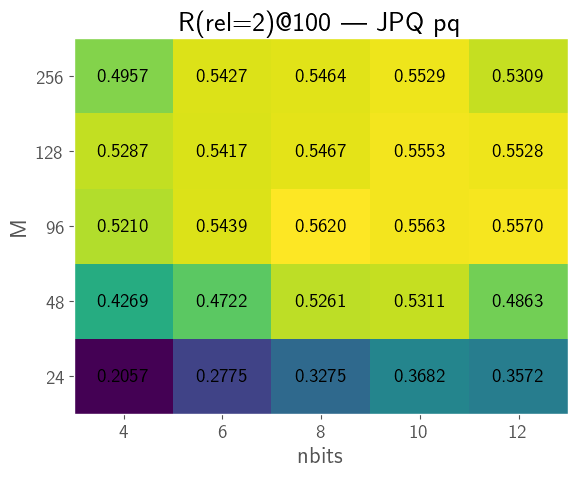

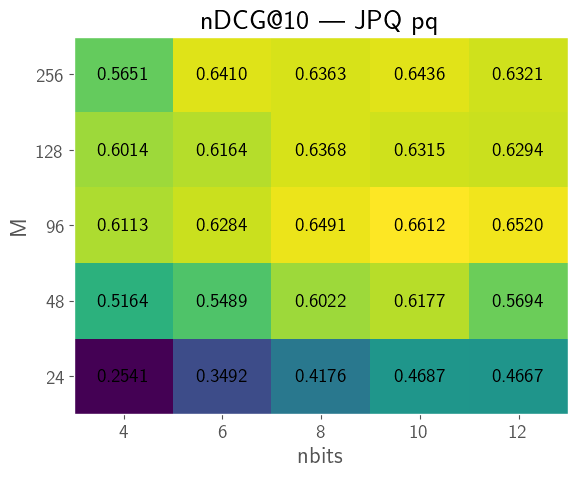

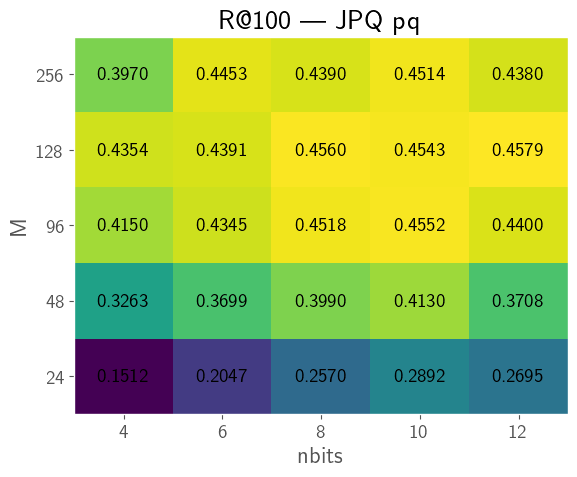

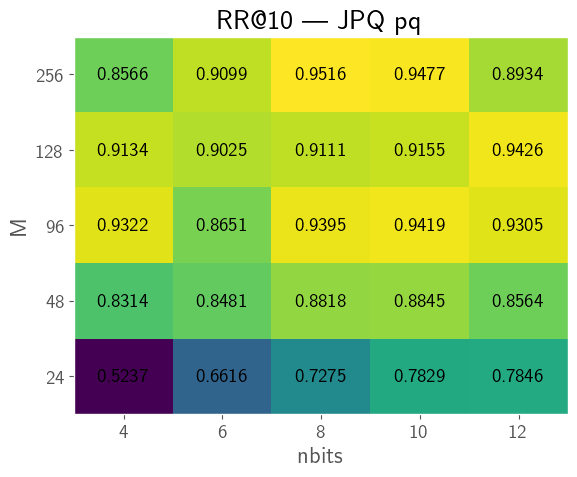

In [21]:
metrics = ["R(rel=2)@100", "nDCG@10", "R@100", "RR@10"]

for m in metrics:
    if m in df.columns:
        plot_metric_heatmap(df, m, variant="JPQ pq")

In [34]:
import matplotlib.pyplot as plt

def plot_summary(df: pd.DataFrame, metric: str, title_suffix: str = ""):
    """
    Plot metric vs nbits, grouped by M, for variant 'JPQ pq'.
    Also shows baseline as a horizontal line if present.
    """
    jpq = df[df["variant"] == "JPQ pq"].copy()
    if jpq.empty:
        print(f"[WARN] No JPQ pq rows found for metric {metric}")
        return

    # sort for nice lines
    jpq = jpq.sort_values(["M", "nbits"])

    fig, ax = plt.subplots(figsize=(8, 5))
    for M_val, group in jpq.groupby("M"):
        ax.plot(
            group["nbits"],
            group[metric],
            marker="o",
            label=f"M={M_val}",
        )

    # Baseline: assume it's the same across runs, just take first if available
    baselines = df[df["variant"] == "baseline"]
    if not baselines.empty and metric in baselines.columns:
        baseline_val = baselines.iloc[0][metric]
        ax.axhline(
            baseline_val,
            color="grey",
            linestyle="--",
            linewidth=1,
            label="baseline",
        )

    ax.set_xlabel("nbits")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs nbits {title_suffix}".strip())
    ax.grid(True, alpha=0.3)
    ax.legend()

    return fig, ax

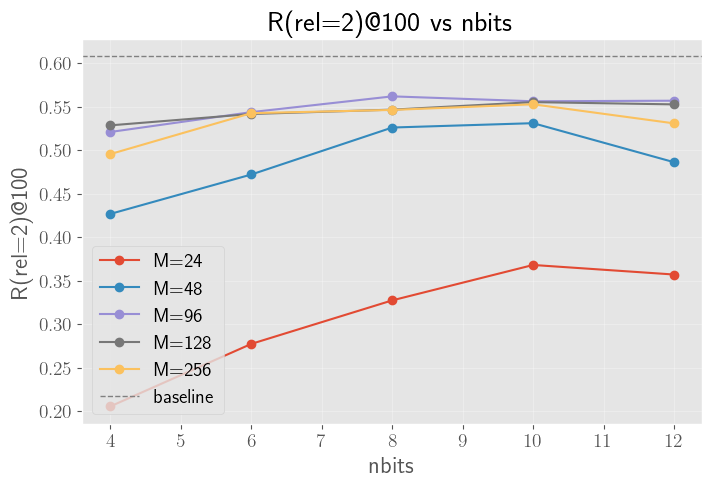

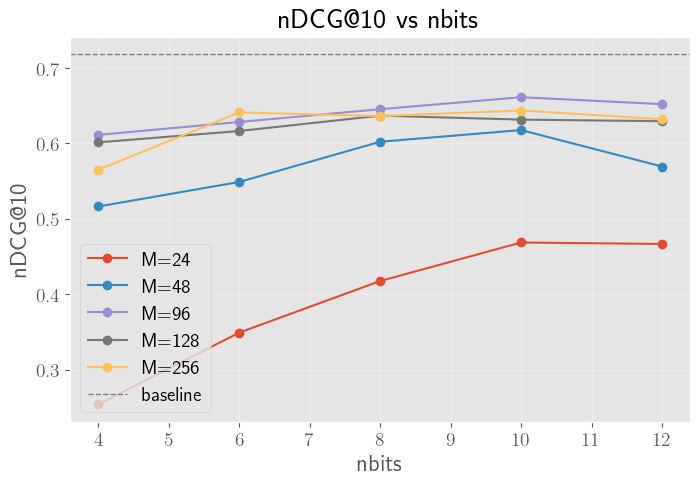

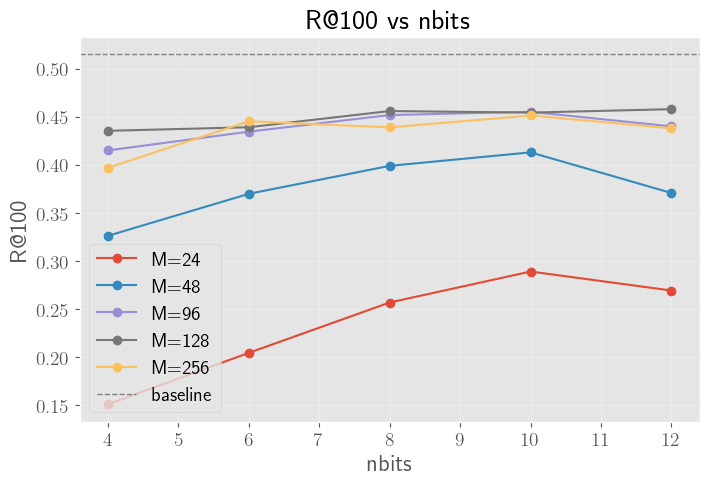

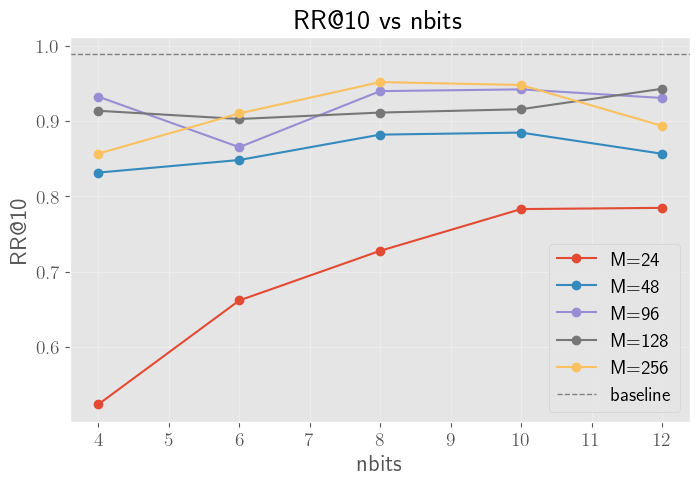

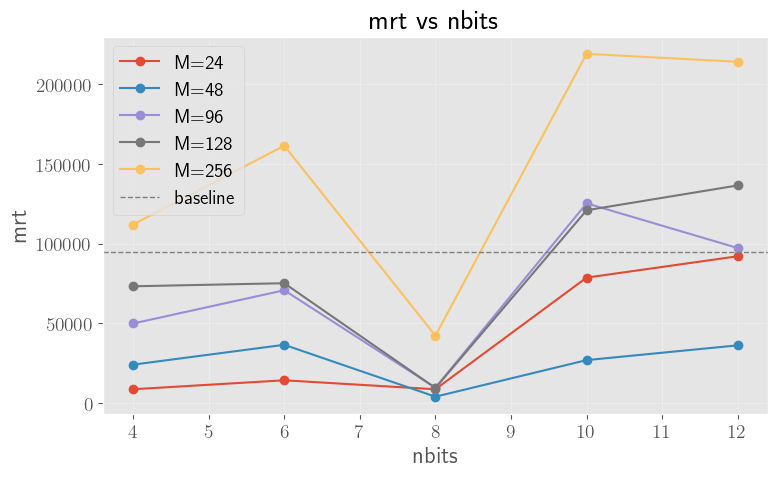

In [35]:
df = collect_all_results(Path('Mbitsscan/'), split='2019')

# One figure per metric
metrics = ["R(rel=2)@100", "nDCG@10", "R@100", "RR@10", "mrt"]
for metric in metrics:
    if metric not in df.columns:
        print(f"[WARN] Metric {metric} not found in dataframe columns.")
        continue
    plot_summary(df, metric)

plt.tight_layout()
plt.show()

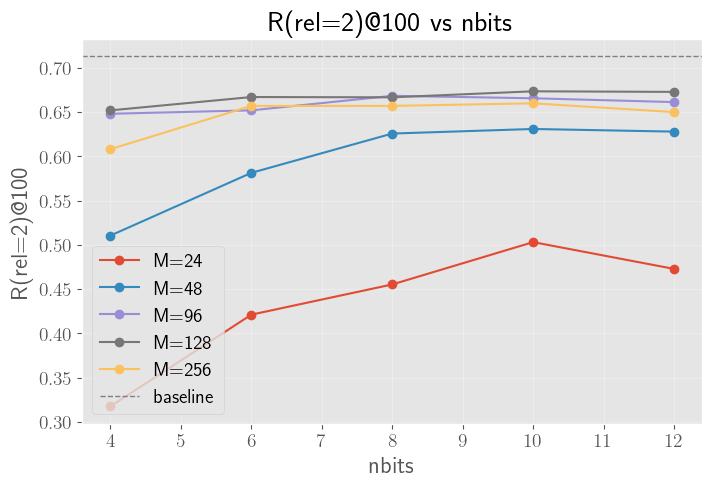

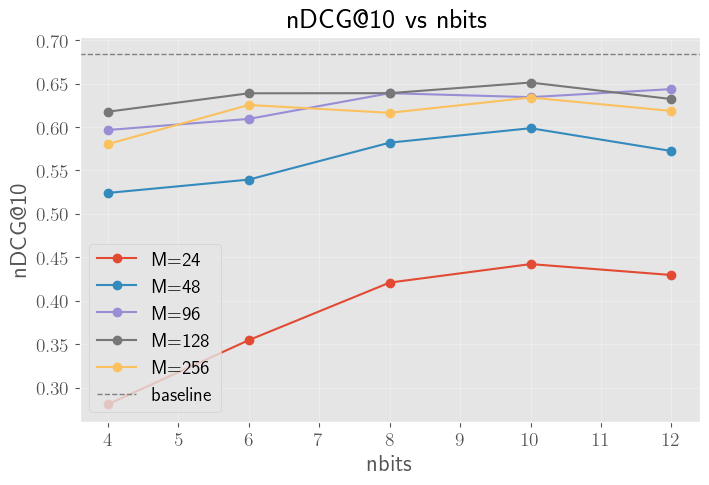

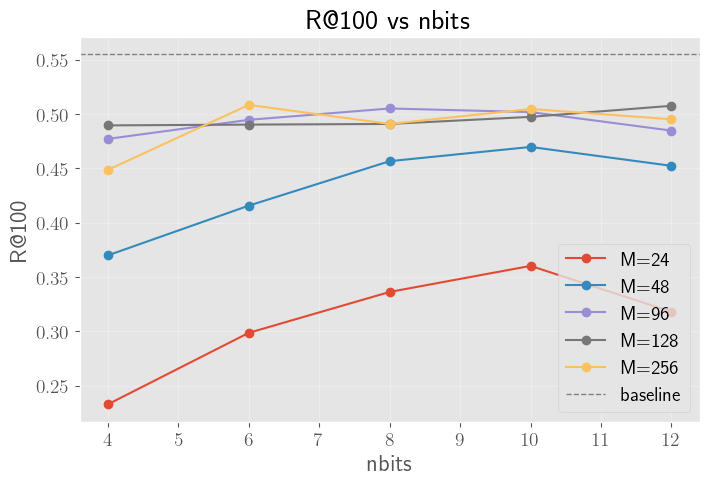

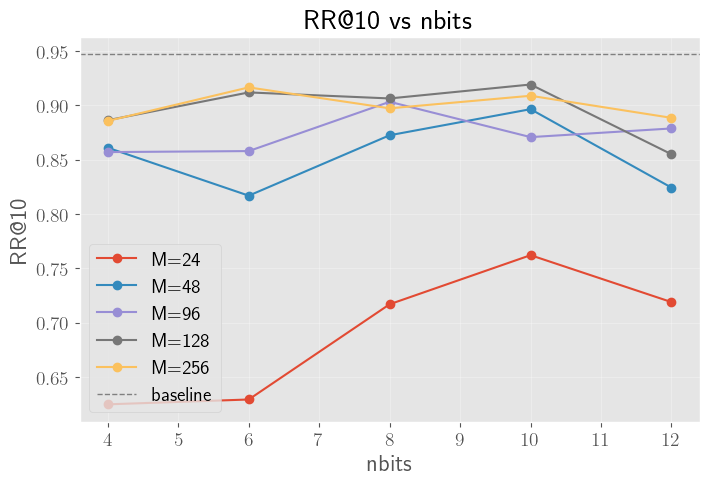

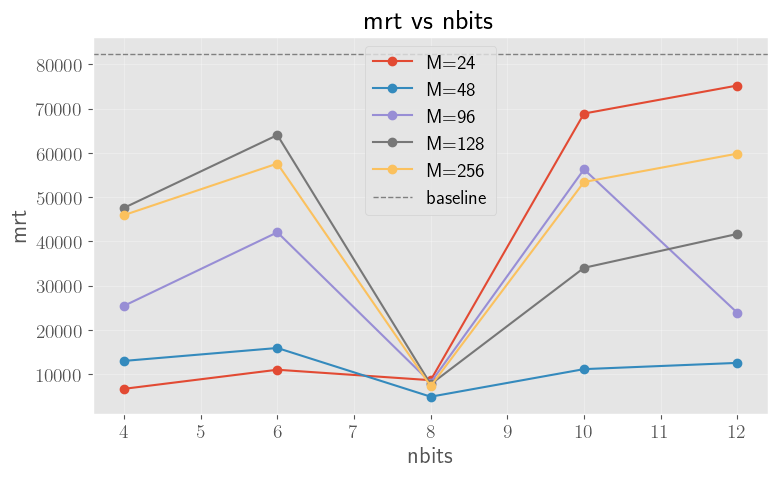

In [36]:
df = collect_all_results(Path('Mbitsscan/'), split='2020')
metrics = ["R(rel=2)@100", "nDCG@10", "R@100", "RR@10", "mrt"]
for metric in metrics:
    if metric not in df.columns:
        print(f"[WARN] Metric {metric} not found in dataframe columns.")
        continue
    plot_summary(df, metric)

plt.tight_layout()
plt.show()